# Repurchase Prediction and Product Recommendation

**Synthetic-data case study.** This notebook estimates when a customer may buy again, recommends what to offer, and combines those outputs into one actionable customer view.

## 1. Repurchase Business Question

Which existing customers are likely to purchase in the next 45 days? The use case is campaign prioritization, where ranking and recall/precision trade-offs matter more than raw accuracy.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "sample"
ASSET_DIR = PROJECT_ROOT / "assets"
ASSET_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
HORIZON_DAYS = 45

customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
products = pd.read_csv(DATA_DIR / "products.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv")

## 2. Target Definition

For each cutoff, features use only orders on or before that date. The target is 1 when the customer purchases in the following 45 days. Looking at future transactions while creating features would leak the answer and overstate model performance.

In [2]:
def build_snapshot(cutoff_date: str) -> pd.DataFrame:
    cutoff = pd.Timestamp(cutoff_date)
    horizon_end = cutoff + pd.Timedelta(days=HORIZON_DAYS)
    history = orders.loc[orders["order_date"].le(cutoff)].copy()
    future = orders.loc[orders["order_date"].gt(cutoff) & orders["order_date"].le(horizon_end)]

    features = history.groupby("customer_id").agg(
        last_purchase=("order_date", "max"),
        first_purchase=("order_date", "min"),
        frequency=("order_id", "nunique"),
        monetary_value=("total_amount", "sum"),
        average_order_value=("total_amount", "mean"),
    ).reset_index()
    features["recency_days"] = (cutoff - features["last_purchase"]).dt.days
    features["days_since_first_purchase"] = (cutoff - features["first_purchase"]).dt.days
    features["average_purchase_interval"] = np.where(
        features["frequency"].gt(1),
        features["days_since_first_purchase"] - features["recency_days"],
        np.nan,
    ) / features["frequency"].sub(1).clip(lower=1)

    recent_start = cutoff - pd.Timedelta(days=90)
    recent = history.loc[history["order_date"].gt(recent_start)].groupby("customer_id").agg(
        orders_last_90d=("order_id", "nunique"),
        spend_last_90d=("total_amount", "sum"),
    ).reset_index()

    history_items = (
        history[["order_id", "customer_id"]]
        .merge(order_items, on="order_id")
        .merge(products[["product_id", "category"]], on="product_id")
    )
    diversity = history_items.groupby("customer_id")["category"].nunique().rename("unique_categories").reset_index()

    snapshot = (
        features.merge(recent, on="customer_id", how="left")
        .merge(diversity, on="customer_id", how="left")
        .merge(customers, on="customer_id", how="left")
    )
    snapshot[["orders_last_90d", "spend_last_90d"]] = snapshot[["orders_last_90d", "spend_last_90d"]].fillna(0)
    snapshot["customer_tenure_days"] = (cutoff - snapshot["signup_date"]).dt.days
    positive_customers = set(future["customer_id"])
    snapshot["repurchased_45d"] = snapshot["customer_id"].isin(positive_customers).astype(int)
    snapshot["cutoff_date"] = cutoff
    return snapshot

example_snapshot = build_snapshot("2025-09-30")
example_snapshot[["customer_id", "recency_days", "frequency", "repurchased_45d"]].head()

,customer_id,recency_days,frequency,repurchased_45d
0,C0001,30,3,1
1,C0002,12,11,0
2,C0003,48,5,1
3,C0004,421,3,0
4,C0005,369,1,0


## 3. Temporal Train/Test Split

Earlier snapshots train the models. The test snapshot begins only after every training target window has closed, which mirrors scoring future customers and avoids random-split leakage.

In [3]:
TRAIN_CUTOFFS = ["2025-02-28", "2025-04-30", "2025-06-30", "2025-08-15", "2025-09-30"]
TEST_CUTOFF = "2025-11-15"
train_data = pd.concat([build_snapshot(date) for date in TRAIN_CUTOFFS], ignore_index=True)
test_data = build_snapshot(TEST_CUTOFF)

split_summary = pd.DataFrame({
    "split": ["Train snapshots", "Test snapshot"],
    "rows": [len(train_data), len(test_data)],
    "positive_rate": [train_data["repurchased_45d"].mean(), test_data["repurchased_45d"].mean()],
    "latest_feature_date": [max(pd.to_datetime(TRAIN_CUTOFFS)), pd.Timestamp(TEST_CUTOFF)],
})
split_summary.style.format({"positive_rate": "{:.1%}", "latest_feature_date": "{:%Y-%m-%d}"})

,split,rows,positive_rate,latest_feature_date
0,Train snapshots,15660,40.1%,2025-09-30
1,Test snapshot,3713,38.0%,2025-11-15


In [4]:
numeric_features = [
    "recency_days", "frequency", "monetary_value", "average_order_value",
    "days_since_first_purchase", "average_purchase_interval", "orders_last_90d",
    "spend_last_90d", "unique_categories", "customer_tenure_days",
]
categorical_features = ["country", "acquisition_channel"]
feature_columns = numeric_features + categorical_features
X_train, y_train = train_data[feature_columns], train_data["repurchased_45d"]
X_test, y_test = test_data[feature_columns], test_data["repurchased_45d"]

linear_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
dense_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

def classification_metrics(y_true, probabilities, threshold=0.50):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities),
    }

## 4. Baseline Model

Logistic Regression is the interpretable baseline. Class weighting keeps the model attentive to the minority positive class.

In [5]:
logistic_model = Pipeline([
    ("preprocess", linear_preprocessor),
    ("model", LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE)),
])
logistic_model.fit(X_train, y_train)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

## 5. Stronger Model

A histogram gradient-boosted tree captures non-linear recency and frequency effects while staying within scikit-learn.

In [6]:
stronger_model = Pipeline([
    ("preprocess", dense_preprocessor),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.06, max_iter=180, max_leaf_nodes=15,
        min_samples_leaf=35, l2_regularization=1.0, random_state=RANDOM_STATE,
    )),
])
stronger_model.fit(X_train, y_train)
stronger_probabilities = stronger_model.predict_proba(X_test)[:, 1]

## 6. Model Evaluation

PR-AUC is emphasized because it measures positive-class ranking against the actual class prevalence. Precision, recall, F1, ROC-AUC, and the confusion matrix provide complementary views; accuracy is intentionally not the headline metric.

In [7]:
model_results = pd.DataFrame([
    {"Model": "Logistic Regression", **classification_metrics(y_test, logistic_probabilities)},
    {"Model": "Gradient Boosting", **classification_metrics(y_test, stronger_probabilities)},
]).set_index("Model")
model_results.round(3)

,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,
Logistic Regression,0.587,0.743,0.656,0.793,0.669
Gradient Boosting,0.656,0.617,0.636,0.811,0.698


## 7. Threshold and Business Interpretation

A 0.50 cutoff is a convention, not a business optimum. For an inexpensive retention message, we select the highest-precision threshold that still reaches at least 70% recall, accepting more contacts to capture more likely repurchasers.

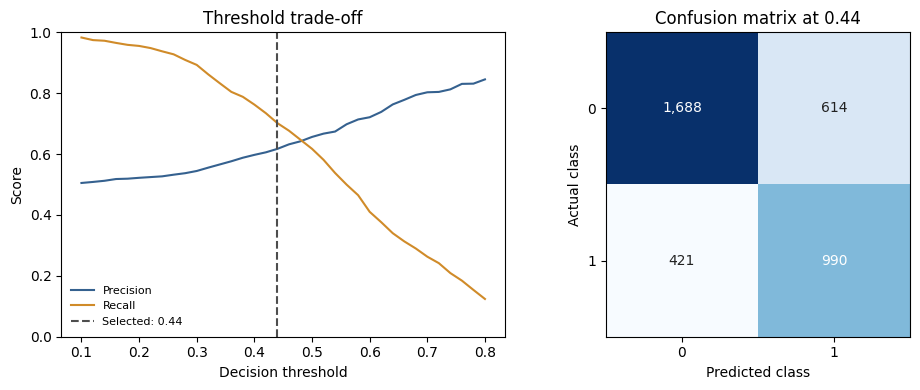

,Precision,Recall,F1,ROC-AUC,PR-AUC
Gradient Boosting @ 0.44,0.617,0.702,0.657,0.811,0.698


In [8]:
thresholds = np.arange(0.10, 0.81, 0.02)
threshold_rows = []
for threshold in thresholds:
    predictions = stronger_probabilities >= threshold
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
    })
threshold_table = pd.DataFrame(threshold_rows)
eligible_thresholds = threshold_table.loc[threshold_table["recall"].ge(0.70)]
selected_threshold = float(eligible_thresholds.sort_values(["precision", "threshold"], ascending=False).iloc[0]["threshold"])
selected_metrics = classification_metrics(y_test, stronger_probabilities, selected_threshold)
selected_predictions = (stronger_probabilities >= selected_threshold).astype(int)
matrix = confusion_matrix(y_test, selected_predictions)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(threshold_table["threshold"], threshold_table["precision"], label="Precision", color="#35618f")
axes[0].plot(threshold_table["threshold"], threshold_table["recall"], label="Recall", color="#d08b29")
axes[0].axvline(selected_threshold, color="#4d4d4d", linestyle="--", label=f"Selected: {selected_threshold:.2f}")
axes[0].set(title="Threshold trade-off", xlabel="Decision threshold", ylabel="Score", ylim=(0, 1))
axes[0].legend(frameon=False, fontsize=8)

image = axes[1].imshow(matrix, cmap="Blues")
for (row, column), value in np.ndenumerate(matrix):
    axes[1].text(column, row, f"{value:,}", ha="center", va="center", color="white" if value > matrix.max() / 2 else "#222222")
axes[1].set(title=f"Confusion matrix at {selected_threshold:.2f}", xlabel="Predicted class", ylabel="Actual class", xticks=[0, 1], yticks=[0, 1])
fig.tight_layout()
fig.savefig(ASSET_DIR / "model_evaluation.png", dpi=180, bbox_inches="tight")
plt.show()
pd.DataFrame([selected_metrics], index=[f"Gradient Boosting @ {selected_threshold:.2f}"]).round(3)

## 8. Product Recommendation

The recommender is intentionally simple: infer each customer's category affinity, then rank popular products inside those categories. Repeat products are allowed because replenishment is a valid e-commerce use case. A leave-last-order-out check reports HitRate@3; it is directional on synthetic data, not an online impact estimate.

In [9]:
dated_items = (
    order_items.merge(orders[["order_id", "customer_id", "order_date"]], on="order_id")
    .merge(products[["product_id", "product_name", "category"]], on="product_id")
)
recommendation_history = dated_items.loc[dated_items["order_date"].le(pd.Timestamp(TEST_CUTOFF))].copy()
order_sequence = (
    recommendation_history[["customer_id", "order_id", "order_date"]]
    .drop_duplicates()
    .sort_values(["customer_id", "order_date", "order_id"])
)
eligible_customers = order_sequence.groupby("customer_id").size().loc[lambda values: values.ge(3)].index
last_orders = order_sequence.loc[order_sequence["customer_id"].isin(eligible_customers)].groupby("customer_id").tail(1)
evaluation_customers = last_orders.sample(min(600, len(last_orders)), random_state=RANDOM_STATE)
holdout_pairs = pd.MultiIndex.from_frame(evaluation_customers[["customer_id", "order_id"]])
history_pairs = pd.MultiIndex.from_frame(recommendation_history[["customer_id", "order_id"]])
recommender_train = recommendation_history.loc[~history_pairs.isin(holdout_pairs)].copy()

category_affinity = recommender_train.groupby(["customer_id", "category"])["quantity"].sum()
category_popularity = (
    recommender_train.groupby(["category", "product_id", "product_name"])["quantity"]
    .sum().rename("units").reset_index()
    .sort_values(["category", "units"], ascending=[True, False])
)
overall_popularity = (
    recommender_train.groupby(["product_id", "product_name"])["quantity"]
    .sum().sort_values(ascending=False).reset_index()
)

def recommend_products(customer_id: str, k: int = 3) -> list[str]:
    recommendations = []
    if customer_id in category_affinity.index.get_level_values(0):
        preferred_categories = category_affinity.loc[customer_id].sort_values(ascending=False).index
        for category in preferred_categories:
            candidates = category_popularity.loc[category_popularity["category"].eq(category), "product_name"]
            for product_name in candidates:
                if product_name not in recommendations:
                    recommendations.append(product_name)
                if len(recommendations) == k:
                    return recommendations
    for product_name in overall_popularity["product_name"]:
        if product_name not in recommendations:
            recommendations.append(product_name)
        if len(recommendations) == k:
            break
    return recommendations

held_out_products = recommendation_history.merge(
    evaluation_customers[["customer_id", "order_id"]], on=["customer_id", "order_id"]
).groupby("customer_id")["product_name"].apply(set)
hits = []
for customer_id, actual_products in held_out_products.items():
    recommended = set(recommend_products(customer_id, k=3))
    hits.append(bool(recommended & actual_products))
hit_rate_at_3 = float(np.mean(hits))
print(f"Leave-last-order-out HitRate@3: {hit_rate_at_3:.1%} across {len(hits):,} synthetic customers")

Leave-last-order-out HitRate@3: 19.8% across 600 synthetic customers


## 9. Example Customer Output

This compact record connects **WHO → WHEN → WHAT → ACTION**.

In [10]:
# Recreate the five-cluster segmentation on the full-history SQL features.
connection = sqlite3.connect(":memory:")
customers.assign(signup_date=customers["signup_date"].dt.strftime("%Y-%m-%d")).to_sql("customers", connection, index=False)
products.to_sql("products", connection, index=False)
orders.assign(order_date=orders["order_date"].dt.strftime("%Y-%m-%d")).to_sql("orders", connection, index=False)
order_items.to_sql("order_items", connection, index=False)
full_features = pd.read_sql_query((PROJECT_ROOT / "sql" / "customer_features.sql").read_text(), connection)
connection.close()

segment_columns = ["recency_days", "frequency", "monetary_value", "average_order_value", "days_since_first_purchase", "average_purchase_interval", "unique_categories"]
segment_frame = full_features[segment_columns].copy()
segment_frame["average_purchase_interval"] = segment_frame["average_purchase_interval"].fillna(segment_frame["average_purchase_interval"].median())
skewed = ["recency_days", "frequency", "monetary_value", "average_order_value", "average_purchase_interval"]
segment_frame[skewed] = np.log1p(segment_frame[skewed])
segment_scaled = StandardScaler().fit_transform(segment_frame)
full_features["cluster"] = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=20).fit_predict(segment_scaled)
profiles = full_features.groupby("cluster").agg(
    average_recency=("recency_days", "mean"), average_frequency=("frequency", "mean"),
    average_monetary_value=("monetary_value", "mean"), average_tenure=("days_since_first_purchase", "mean"),
)
z = (profiles - profiles.mean()) / profiles.std(ddof=0)
remaining = set(profiles.index)
high_value = (z["average_frequency"] + z["average_monetary_value"] - z["average_recency"]).idxmax(); remaining.remove(high_value)
at_risk = z.loc[list(remaining), "average_recency"].idxmax(); remaining.remove(at_risk)
new_promising = z.loc[list(remaining), "average_tenure"].idxmin(); remaining.remove(new_promising)
low_frequency = (z.loc[list(remaining), "average_frequency"] + z.loc[list(remaining), "average_monetary_value"]).idxmin(); remaining.remove(low_frequency)
segment_map = {high_value: "High Value Loyal", remaining.pop(): "Loyal Customers", new_promising: "New / Promising", at_risk: "At Risk", low_frequency: "Low Frequency"}
full_features["segment"] = full_features["cluster"].map(segment_map)

scored_customers = test_data[["customer_id"]].copy()
scored_customers["repurchase_probability"] = stronger_probabilities
scored_customers = scored_customers.merge(full_features[["customer_id", "segment"]], on="customer_id")
example_customer = scored_customers.sort_values("repurchase_probability", ascending=False).iloc[25]
recommendations = recommend_products(example_customer["customer_id"], 3)
action_by_segment = {
    "High Value Loyal": "VIP retention and personalized cross-sell",
    "Loyal Customers": "Loyalty reward and replenishment reminder",
    "New / Promising": "Second-order onboarding offer",
    "At Risk": "Reactivation campaign",
    "Low Frequency": "Low-cost nurture campaign",
}
customer_intelligence_output = pd.DataFrame({
    "Field": ["Customer ID", "Segment", "Repurchase probability", "Recommended products", "Suggested business action"],
    "Value": [example_customer["customer_id"], example_customer["segment"], f"{example_customer['repurchase_probability']:.1%}", " | ".join(recommendations), action_by_segment[example_customer["segment"]]],
})
customer_intelligence_output

,Field,Value
0,Customer ID,C2911
1,Segment,High Value Loyal
2,Repurchase probability,86.4%
3,Recommended products,Home Item 02 | Home Item 01 | Home Item 03
4,Suggested business action,VIP retention and personalized cross-sell


## 10. Production Monitoring

- **Model:** PR-AUC, precision, recall, calibration, and the prediction distribution.
- **System:** scoring/API latency, error rate, and uptime.
- **Data and model drift:** customer-feature distributions, category mix, prediction drift, and delayed-label performance degradation.
- **Business:** conversion, repurchase rate, revenue per customer, campaign uplift, recommendation CTR, and incremental revenue.

A lightweight batch score or API could be containerized, but infrastructure is intentionally outside this portfolio scope. Online A/B testing is required to establish causal business impact.

## 11. Final Takeaways

- Temporal snapshots keep future purchases out of feature engineering.
- Logistic Regression provides an interpretable baseline; gradient boosting adds non-linear capacity.
- Thresholds should reflect campaign economics, while recommendation quality ultimately needs online validation.